# PROJECT SPEED DATING

## Central question : Why do some people get a second date and others don't?

In [ ]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Loading the Data

In [4]:
import chardet

# Load the dataset
with open('Speed+Dating+Data.csv', 'rb') as f:
    raw_data = f.read()
    result = chardet.detect(raw_data)

detected_encoding = result['encoding']
confidence = result['confidence']
print(f"Detected encoding: {detected_encoding} (confidence: {confidence:.2%})")

Detected encoding: Windows-1252 (confidence: 72.92%)


In [5]:
df = pd.read_csv('Speed+Dating+Data.csv', encoding=detected_encoding)
df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [27]:
#Dataset structure
df.shape
df.info()
df.head()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


Index(['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position',
       'positin1', 'order',
       ...
       'attr3_3', 'sinc3_3', 'intel3_3', 'fun3_3', 'amb3_3', 'attr5_3',
       'sinc5_3', 'intel5_3', 'fun5_3', 'amb5_3'],
      dtype='object', length=195)

In [ ]:
#Missing values
missing_percent = df.isnull().mean() * 100
print(missing_percent)

iid          0.000000
id           0.011936
gender       0.000000
idg          0.000000
condtn       0.000000
              ...    
attr5_3     75.936978
sinc5_3     75.936978
intel5_3    75.936978
fun5_3      75.936978
amb5_3      75.936978
Length: 195, dtype: float64


In [15]:
#Verifier les doublons
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
#Descriptif du Dataset
df.describe(include='all')

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000


In [38]:
df["gender"].value_counts()

gender
1    4194
0    4184
Name: count, dtype: int64

## Distribution of Goals according to Gender

In [ ]:
#Isoler les valeurs concernées par la question
df_gender_goal = df[['gender', 'goal']]
print(df_gender_goal)

      gender  goal
0          0   2.0
1          0   2.0
2          0   2.0
3          0   2.0
4          0   2.0
...      ...   ...
8373       1   1.0
8374       1   1.0
8375       1   1.0
8376       1   1.0
8377       1   1.0

[8378 rows x 2 columns]


In [11]:
df_gender_goal.info()
df_gender_goal.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  8378 non-null   int64  
 1   goal    8299 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 131.0 KB


,gender,goal
count,8378.000000,8299.000000
mean,0.500597,2.122063
std,0.500029,1.407181
min,0.000000,1.000000
25%,0.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,1.000000,6.000000


In [ ]:
# Visualisation Boxplot
import plotly.express as px

px.box(df_gender_goal, x="gender", y="goal", title="Distribution of Goals according to Gender")

<Axes: xlabel='goal', ylabel='Count'>

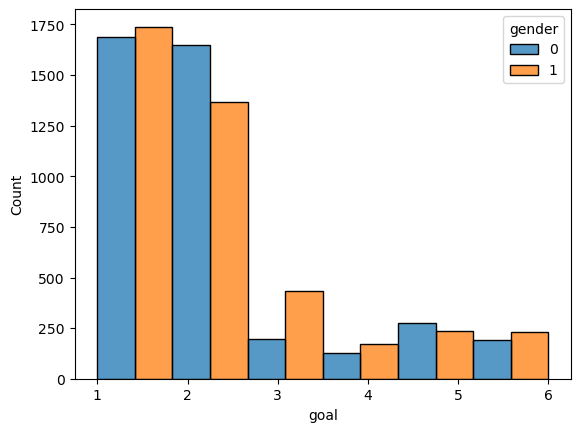

In [ ]:
#Visualisation Histogramme
sns.histplot(data=df_gender_goal, x="goal", hue="gender", multiple="dodge", bins=6)

In [54]:
#
df2 = df[['gender', 'match']].dropna()
df.groupby("gender")[["match"]].count()
print(df2.head)

<bound method NDFrame.head of       gender  match
0          0      0
1          0      0
2          0      1
3          0      1
4          0      1
...      ...    ...
8373       1      0
8374       1      0
8375       1      0
8376       1      0
8377       1      0

[8378 rows x 2 columns]>


<Axes: xlabel='gender', ylabel='age'>

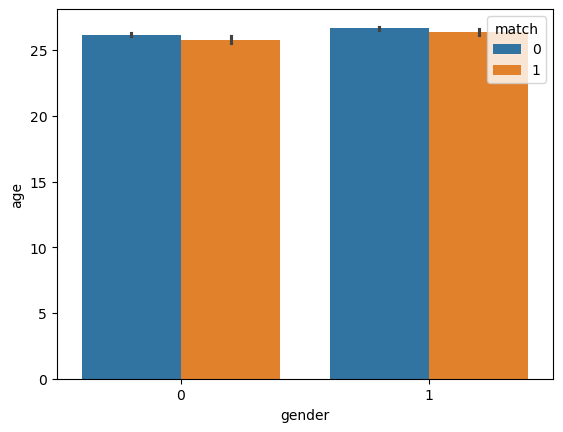

In [55]:
sns.barplot(x="gender", y="age", hue="match", data=df)